In [2]:
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt

In [3]:
gdf = gpd.read_file("../src/exports/ghe_locations.geojson")

In [4]:
# gdf.reset_index().explore(tooltip='index')
gdf.explore()

In [5]:
# Load elevation raster
with rasterio.open("../src/imports/elevation_data.tif") as src:
    raster_src = src
    elevation = src.read(1)
    raster_extent = [
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top,
    ]
    raster_crs = src.crs

    downsample_factor = 1
    new_height = int(src.height * downsample_factor)
    new_width = int(src.width * downsample_factor)

    z_data = src.read(
        1,
        out_shape=(new_height, new_width),
        resampling=Resampling.bilinear
    )

# Make sure GeoJSON uses the same CRS as the raster
if gdf.crs != raster_crs:
    gdf = gdf.to_crs(raster_crs)

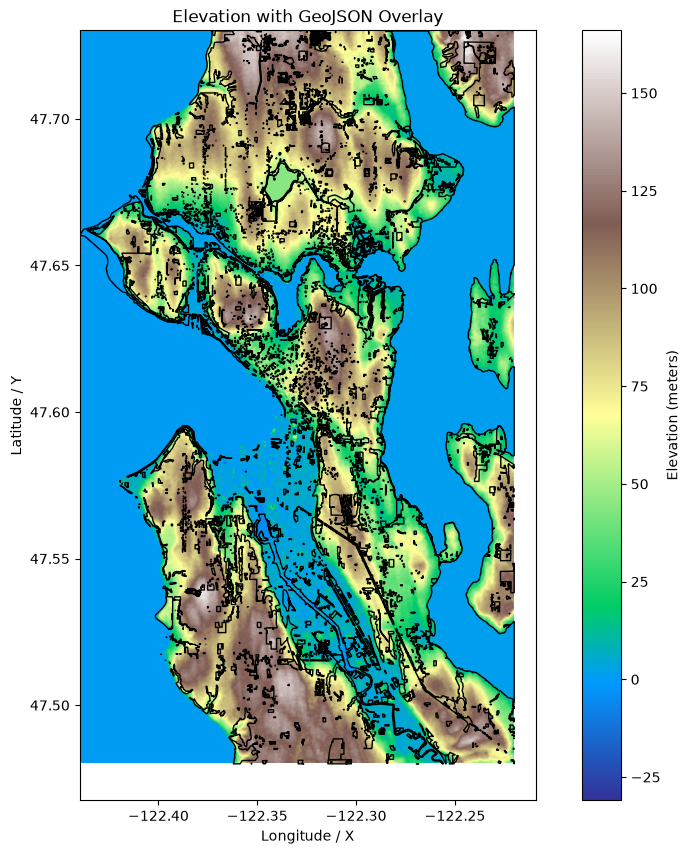

In [6]:
# Create plot
fig, ax = plt.subplots(figsize=(12, 10))

# Display elevation
image = ax.imshow(
    elevation,
    extent=raster_extent,
    cmap="terrain",
    origin="upper"
)

# Overlay GeoJSON
gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.0
)

# Elevation legend/colorbar
cbar = fig.colorbar(image, ax=ax)
cbar.set_label("Elevation (meters)")

ax.set_xlabel("Longitude / X")
ax.set_ylabel("Latitude / Y")
ax.set_title("Elevation with GeoJSON Overlay")

plt.show()